## Aim
The aim of this model is to allow for the creation of arbitrary molecules, e.g. the elements will be hardcoded but molecules will not be. The model doesn't need to be completely accurate; I want to incorporate a simplified simulation that still encompasses the interesting bits from chemistry such as distillation, reactions, etc. To add to the complexity, mods should be able to define how their materials are composed and be able to modify things without breaking the whole mod. Ideally this should be achieved via datapacks.

## Elements
The elements used will not be real life elements, but instead elements inspired by alchemy. This system will utilise the cardinal elements (Terra, Aqua, Aer, Ignis) and the tria prima (Salt, Sulphur, Mercury). Cardinal elements cannot bond to themselves, for example terra cannot bond to terra, aqua, aer, nor ignis. The tria prima are able to bond to themselves, and are also able to form a core that the cardinal elements can form a shell around (including different types). For example, the core can consist of salt and mercury, with a shell of aqua and ignis. The shells form in order of elements, with terra being closest to the core, and ignis the furthest away.

A core with a higher elemental shell will have greater difficulty bonding to a lower one, e.g. a salt core with aer shell will find it very difficult to bond to aqua, and even more difficult to bond to terra, but easily bond with ignis.

## Cosmology
The tria prima correspond to each of the 3 dimensions in Minecraft.
- Salt - Overworld
- Sulphur - Nether
- Mercury - End

If Mojang were to add a Sculk dimension, then this would correspond to Salt and the Overworld would instead be the interstice between those 3 dimensions. The matter in each of these dimensions would primarily have cores of their corresponding tria prima, e.g. Endstone would be made of something with a core of mercury plus some other cardinal elements.

The Sun and Moon correspond to Sulphur and Mercury respectively. "Singing" to the Sun and Moon will cause their rays to transform and influence chemical reactions. Some reactions will become easier depending on the time of day, phase of moon, and location.

## Metals
Gold, Iron, and Silver correspond to Sulphur, Salt, and Mercury in their perfected, crystalline forms. The properties of metals change as they come closer to their affinities, e.g. the strength of gold/silver depends on the position of the Sun/Moon and is stronger in the Nether/End, silver is affected by the phase of the moon, iron becomes stronger deeper underground, etc.

## Transmutation
Trees should be able to transmute the air and water into mass to build their trunks, and the player should be able to replicate this process chemically.

Netherrack should be able to burn indefinitely by transmuting the air into fire, though this flame will not be as hot as other means.

In [14]:
from matplotlib import pyplot as plt
from matplotlib.path import Path
import matplotlib.patches as patches

# Maximum number of elements in a block must fit in a 64-bit unsigned integer (2^64-1)
# but ideally should be a multiple of 16^3 so it can fit in the pixel of a 16x16x16 block
ELEMENTS_PER_BLOCK = 18_446_744_073_709_547_520  # (2^64 / 16^3 - 1) * 16^3

In [15]:
class Element:
    def __init__(self, name: str, mass: int) -> None:
        self.name = name
        self.mass = mass

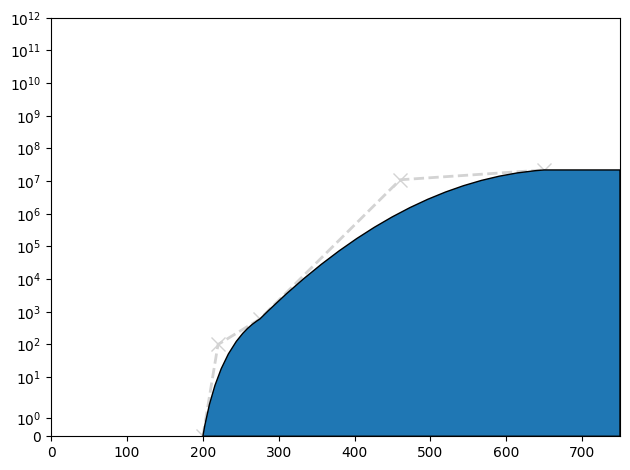

In [16]:
T_MAX = 750
P_MAX = 1e12

verts = (
    (200, 0),
    (220, 100),
    (275, 600),  # Triple point
    (460, 11e6),
    (650, 22e6),  # Critical point
    (T_MAX, 22e6),
    (T_MAX, 0),
    (200, 0),  # Close path
)

codes = (
    Path.MOVETO,
    Path.CURVE3,
    Path.CURVE3,  # Triple point
    Path.CURVE3,
    Path.CURVE3,  # Critical point
    Path.LINETO,
    Path.LINETO,
    Path.CLOSEPOLY,
)

fig, ax = plt.subplots()
path = Path(verts, codes)
patch = patches.PathPatch(path, facecolor='tab:blue', lw=1)
ax.add_patch(patch)

xs, ys = zip(*verts)
xs, ys = xs[:-3], ys[:-3]
ax.plot(xs, ys, 'x--', lw=2, color='lightgray', ms=10, zorder=0)

ax.set_yscale('symlog')
ax.set_xlim(0, T_MAX)
ax.set_ylim(0, P_MAX)
plt.tight_layout()
plt.show()

In [17]:
AQUA = Element('aqua', 4)
IGNIS = Element('ignis', 1)
AER = Element('aer', 2)
TERRA = Element('terra', 8)